In [ ]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import xarray as xr

et_ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration_resampled_NN.nc")
sm_ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_Crop.nc")
ro_ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff_cropped_resampled.nc")
gw_ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
precip_ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/Rainfall_Resample_Cropped.nc")

In [ ]:
precip = precip_ds["satellite_precip"]   # mm/day
et = et_ds["ET"]                         # mm/month
sm = sm_ds["sm"]                         # m3/m3
ro = ro_ds["ro"]                         # m
gw = gw_ds["GWS_tavg"]                   # cm

In [ ]:
ro = ro.rename({
    "latitude": "lat",
    "longitude": "lon",
    "valid_time": "time"
})

In [ ]:
precip = precip.sortby(["lat","lon"])
et = et.sortby(["lat","lon"])
sm = sm.sortby(["lat","lon"])
ro = ro.sortby(["lat","lon"])
gw = gw.sortby(["lat","lon"])

In [ ]:
# Precip: mm/day → mm/month
precip = precip * precip.time.dt.days_in_month

# ET already mm/month
et = et

# Runoff: m → mm
ro = ro * 1000

# Groundwater: cm → mm
gw = gw * 10

# Soil moisture: m3/m3 → mm
root_depth = 1.0   # meters
sm = sm * root_depth * 1000

In [ ]:
storage = sm + gw
delta_storage = storage.diff("time")

In [ ]:
common_time = delta_storage.time

precip = precip.reindex(time=common_time, method="nearest")
et = et.reindex(time=common_time, method="nearest")
ro = ro.reindex(time=common_time, method="nearest")

In [ ]:
lat_ref = precip.lat
lon_ref = precip.lon

et = et.interp(lat=lat_ref, lon=lon_ref)
ro = ro.interp(lat=lat_ref, lon=lon_ref)
delta_storage = delta_storage.interp(lat=lat_ref, lon=lon_ref)

In [ ]:
precip, et, ro, delta_storage = xr.align(
    precip, et, ro, delta_storage,
    join="inner",
    exclude=["lat","lon"]
)

In [ ]:
residual = precip - (et + ro + delta_storage)

In [ ]:
print("Type:", type(residual))
print("Shape:", residual.shape)
print("Min/Max:", float(residual.min()), float(residual.max()))

Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (262, 67, 73)
Min/Max: -413.1964018621302 704.5150780494731


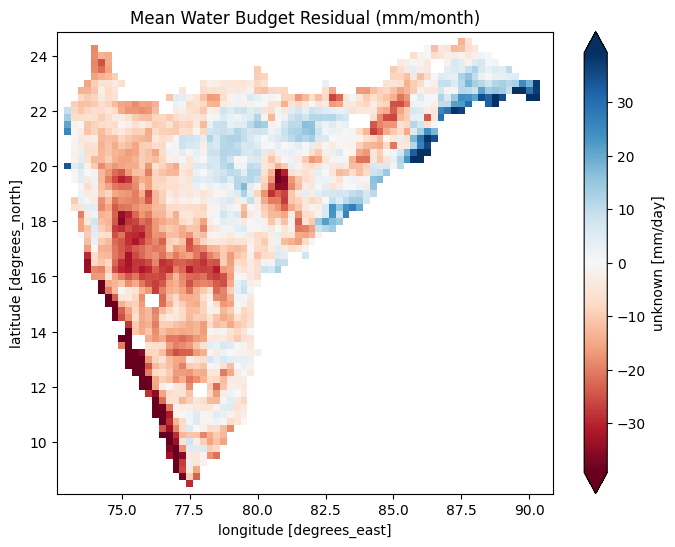

In [ ]:
mean_residual = residual.mean(dim="time")

plt.figure(figsize=(8,6))
mean_residual.plot(cmap="RdBu", robust=True)
plt.title("Mean Water Budget Residual (mm/month)")
plt.show()

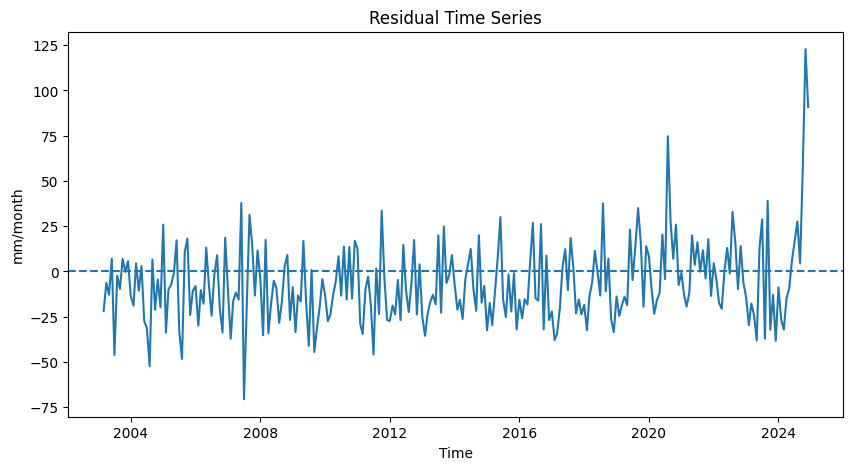

In [ ]:
ts = residual.mean(dim=["lat","lon"])

plt.figure(figsize=(10,5))
ts.plot()
plt.axhline(0, linestyle="--")
plt.title("Residual Time Series")
plt.ylabel("mm/month")
plt.show()

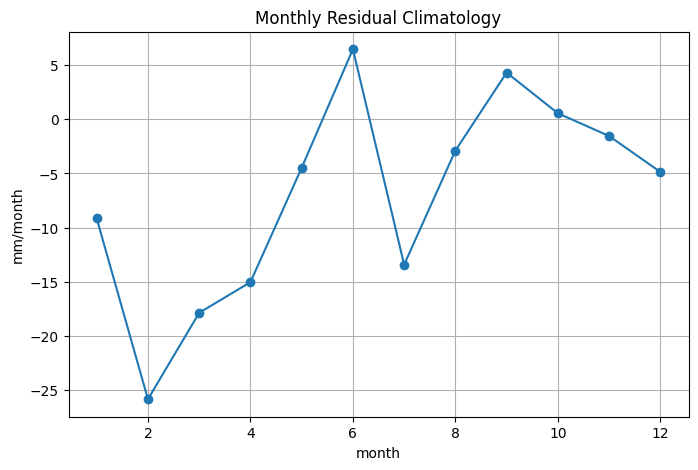

In [ ]:
clim = residual.mean(dim=["lat","lon"]).groupby("time.month").mean()

plt.figure(figsize=(8,5))
clim.plot(marker='o')
plt.title("Monthly Residual Climatology")
plt.ylabel("mm/month")
plt.grid()
plt.show()

In [ ]:
for name, var in zip(
    ["precip","et","ro","delta_storage"],
    [precip, et, ro, delta_storage]
):
    print(f"{name}: NaNs =", np.isnan(var).sum().values)

precip: NaNs = 720500
et: NaNs = 765302
ro: NaNs = 763206
delta_storage: NaNs = 800048


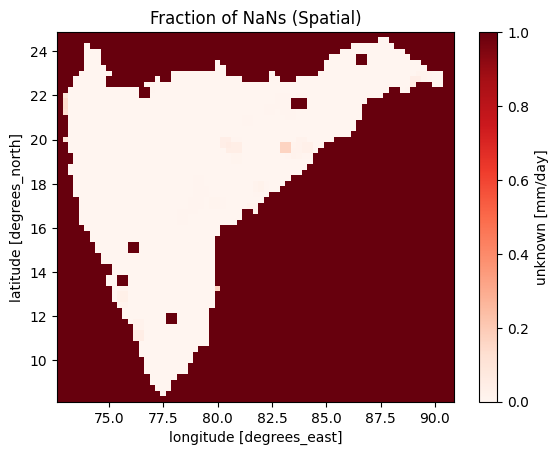

In [ ]:
residual.isnull().mean(dim="time").plot(cmap="Reds")
plt.title("Fraction of NaNs (Spatial)")
plt.show()